# Iris Flower Classification
The Iris flower dataset consists of three species: setosa, versicolor,
and virginica. These species can be distinguished based on their
measurements. Now, imagine that you have the measurements
of Iris flowers categorized by their respective species. Your
objective is to train a machine learning model that can learn from
these measurements and accurately classify the Iris flowers into
their respective species.

Use the Iris dataset to develop a model that can classify iris
flowers into different species based on their sepal and petal
measurements. This dataset is widely used for introductory
classification tasks.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
# import data
df = pd.read_csv("data/IRIS.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


# Basic Descriptive Statistics

In [158]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [160]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Distributions of Features and Targets

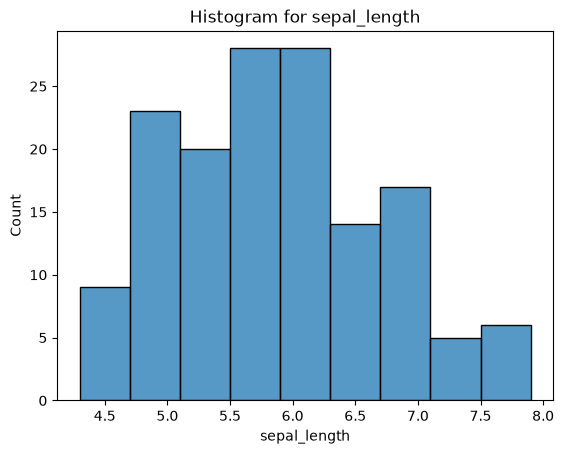

In [14]:
cols = df["sepal_length"]
sns.histplot(cols)
plt.title("Histogram for sepal_length")
plt.show()

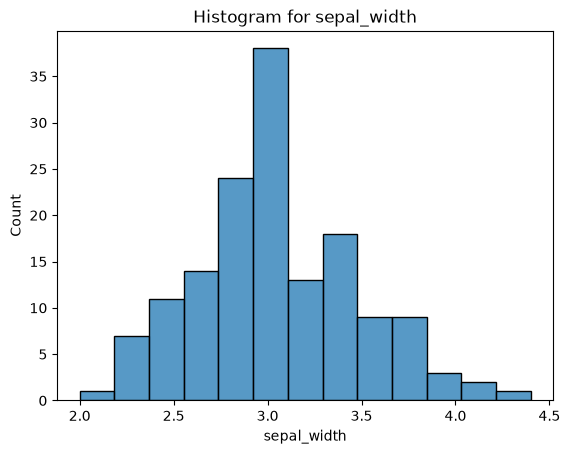

In [15]:
cols = df["sepal_width"]
sns.histplot(cols)
plt.title("Histogram for sepal_width")
plt.show()

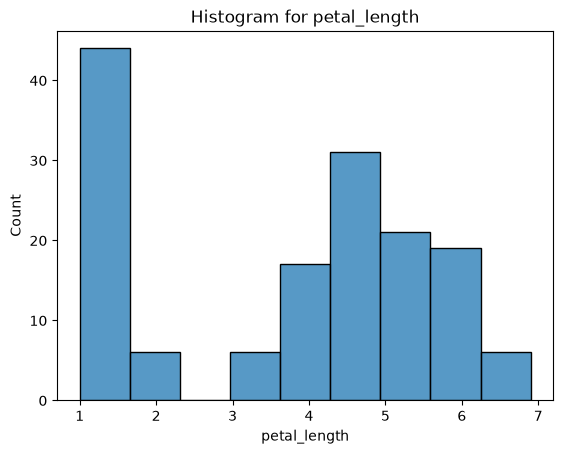

In [16]:
cols = df["petal_length"]
sns.histplot(cols)
plt.title("Histogram for petal_length")
plt.show()

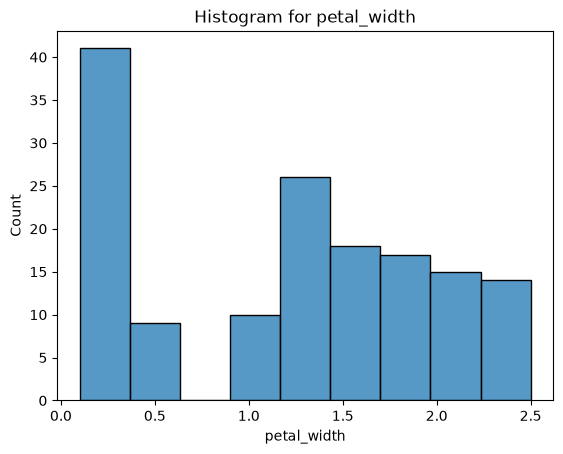

In [17]:
cols = df["petal_width"]
sns.histplot(cols)
plt.title("Histogram for petal_width")
plt.show()

# Relationship of data features with target

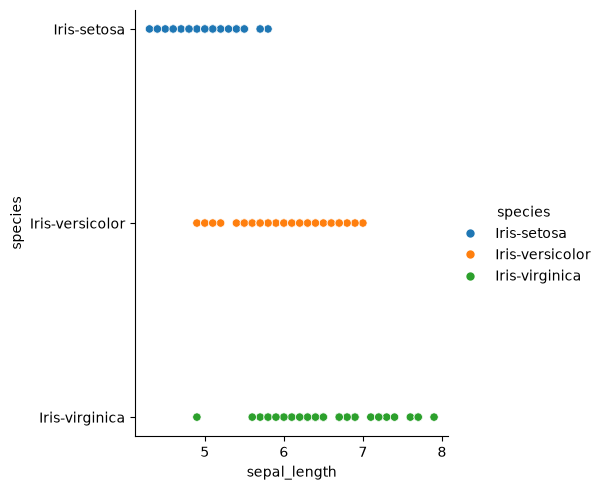

In [18]:
sns.relplot(x="sepal_length", y = "species", hue = "species", data = df)

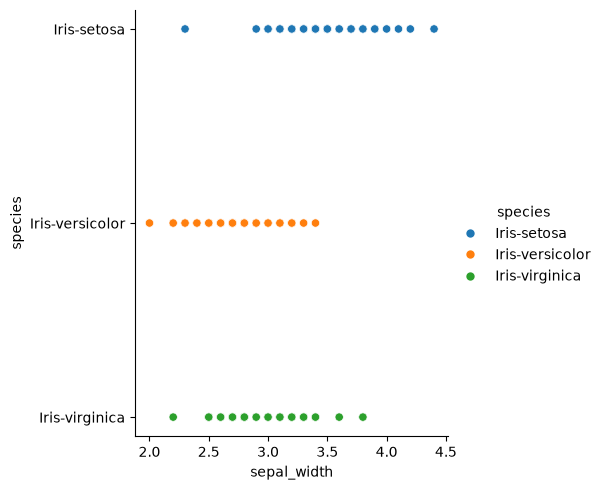

In [19]:
sns.relplot(x="sepal_width", y = "species", hue = "species", data = df)

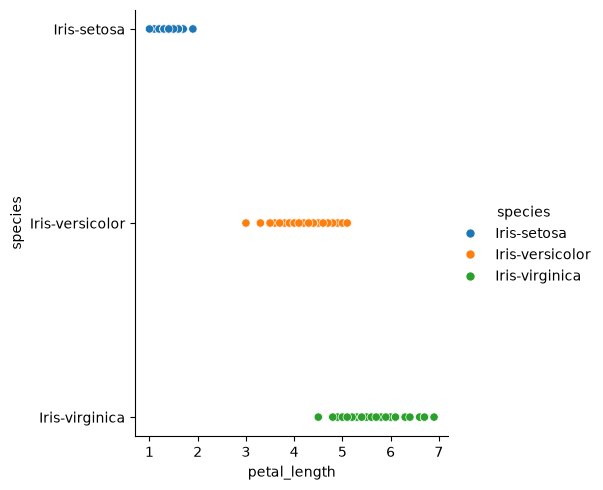

In [20]:
sns.relplot(x="petal_length", y = "species", hue = "species", data = df)

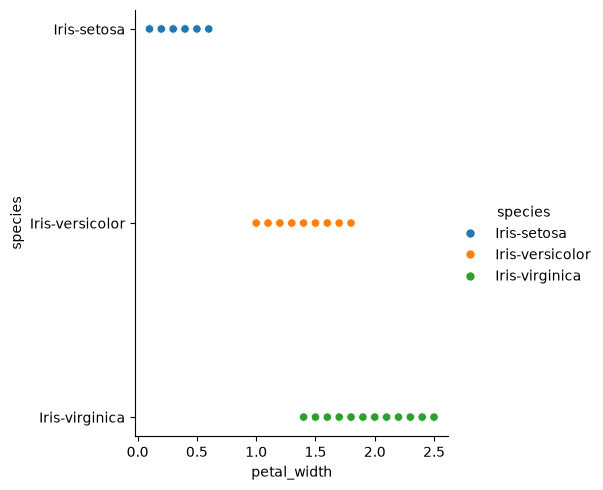

In [21]:
sns.relplot(x="petal_width", y = "species", hue = "species", data = df)

# Exploratory Data Analysis - Pairplots

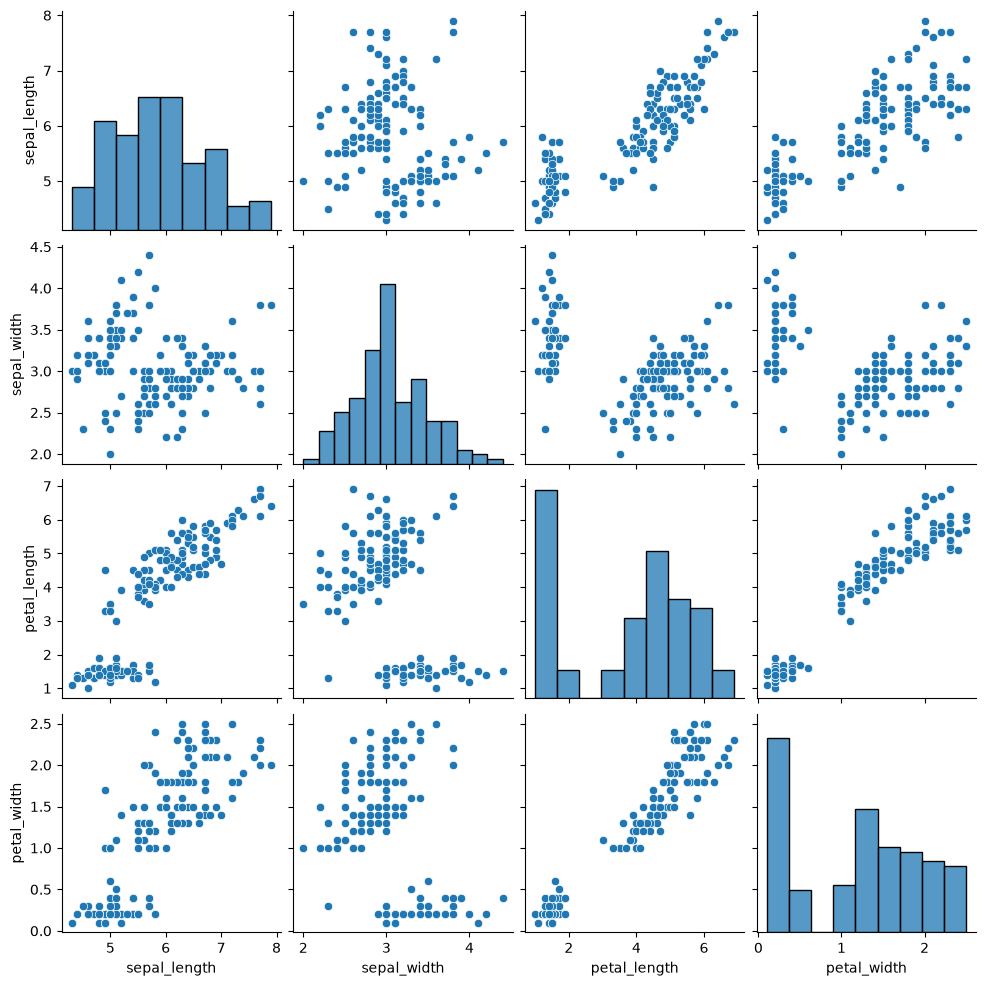

In [24]:
sns.pairplot(df)

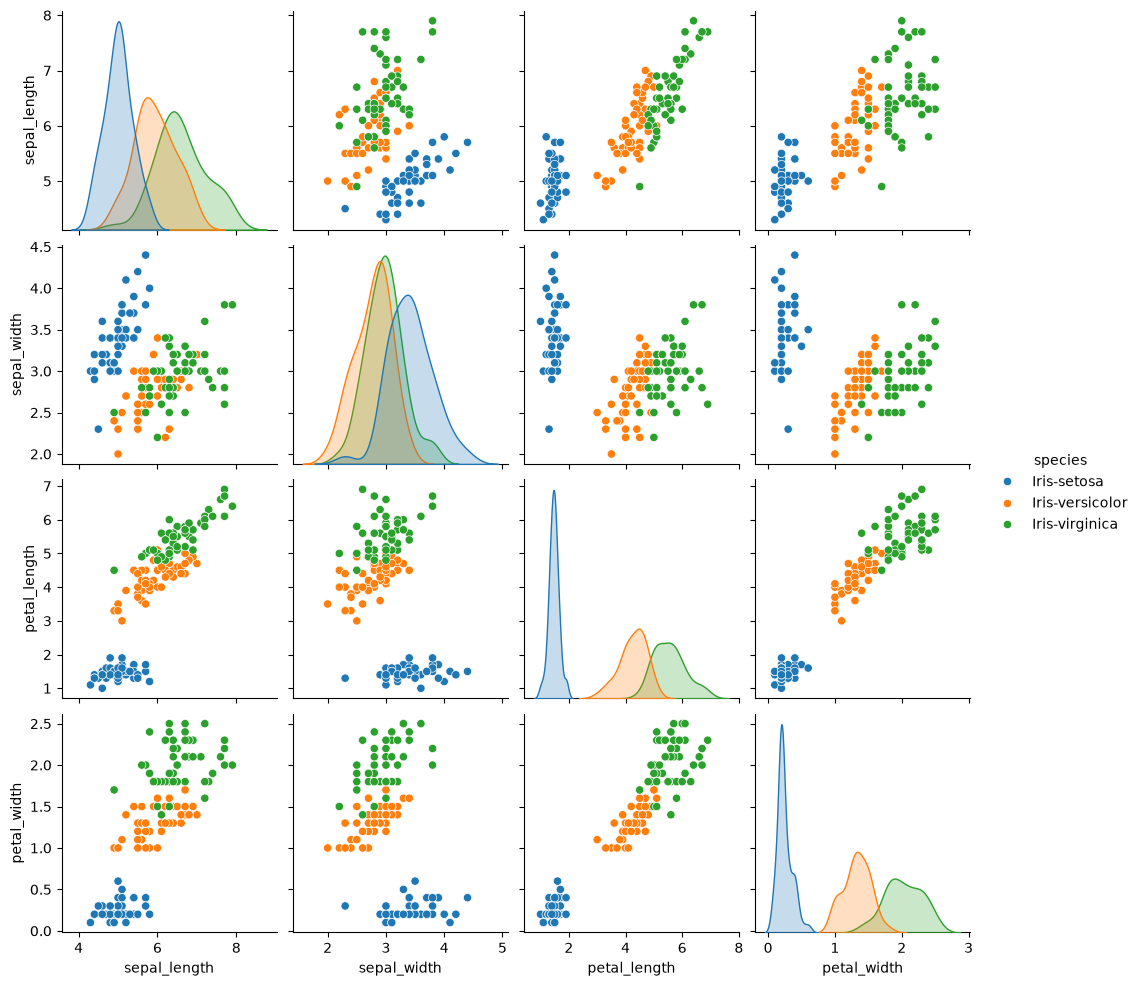

In [25]:
sns.pairplot(df, hue = "species")

In [26]:
# From the above graph we can say that when we use the petal_length and petal_width the data can be easily seperated

# Train Test Split

In [119]:
X = df.drop(columns="species")
y = df["species"]

In [120]:
print(X)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: str

In [121]:
df["species"].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [161]:
# Spliting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

In [162]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(112, 4)
(38, 4)
(112,)
(38,)


# Modeling-Simple manual model

### Using the manual data analysis and decide some cut off points for classification

In [163]:
def single_feature_prediction(petal_length):
    if petal_length < 2.7:
        return "Iris-setosa"
    elif petal_length < 4.8:
        return "Iris-versicolor"
    else:
        return "Iris-virginica"

In [164]:
manual_y_predictions = X_test["petal_length"].apply(single_feature_prediction)
np.mean(y_test == manual_y_predictions) # This is similar to the below function

np.float64(0.9473684210526315)

In [165]:
from sklearn.metrics import accuracy_score

manual_accuracy = accuracy_score(y_test, manual_y_predictions)
print(f"The Manual Model accuracy is: {manual_accuracy * 100:.2f} %")

The Manual Model accuracy is: 94.74 %


# Modeling - Logistic Regressions

In [186]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

In [187]:
print("Actual values: ", y_test.values[:10])
print("Predicted values: ", y_pred[:10])

Actual values:  <StringArray>
[    'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
     'Iris-setosa', 'Iris-versicolor',  'Iris-virginica',  'Iris-virginica',
  'Iris-virginica',  'Iris-virginica']
Length: 10, dtype: str
Predicted values:  ['Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica']


In [188]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38



In [189]:
from sklearn.metrics import accuracy_score

logistic_regression_model_accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the logistic regression is {logistic_regression_model_accuracy * 100 :.2f} %")

The accuracy of the logistic regression is 94.74 %


In [190]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12  0  0]
 [ 0 12  1]
 [ 0  1 12]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38



# Random Forest

In [191]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred = random_forest_model.predict(X_test)

In [192]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.86      0.92      0.89        13
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.92        38
      macro avg       0.92      0.92      0.92        38
   weighted avg       0.92      0.92      0.92        38



In [193]:
from sklearn.metrics import accuracy_score

random_forest_model_accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of random forest is {random_forest_model_accuracy * 100 :.2f}%")

The accuracy of random forest is 92.11%


# Decision Tree

In [194]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
y_pred = decision_tree_model.predict(X_test)

In [195]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.80      0.92      0.86        13
 Iris-virginica       0.91      0.77      0.83        13

       accuracy                           0.89        38
      macro avg       0.90      0.90      0.90        38
   weighted avg       0.90      0.89      0.89        38



In [196]:
from sklearn.metrics import accuracy_score

decision_tree_model_accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the decision tree model is: {decision_tree_model_accuracy * 100:.2f}%")

The accuracy of the decision tree model is: 89.47%


# K-Nearest Neighbors(KNN)

In [197]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

In [198]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.92      0.96        13

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



In [199]:
from sklearn.metrics import accuracy_score

k_nearest_neighbors_model_accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the decision tree model is: {k_nearest_neighbors_model_accuracy * 100:.2f}%")

The accuracy of the decision tree model is: 97.37%


# Using Cross Validation Method to evaluate Model

cross-validation tells you:

"The model's performance is around 96.40% across different subsets of the data."

In [266]:
from sklearn.model_selection import cross_val_predict, cross_val_score

accuracies = cross_val_score(logistic_model,X_train,y_train,cv = 5, scoring="accuracy")
cross_logistic_accuracy = np.mean(accuracies)
print(f"The accuracy of the logistic regression model after with cross validation is: {cross_logistic_accuracy * 100:.2f}%")

accuracies = cross_val_score(decision_tree_model,X_train,y_train,cv = 5, scoring="accuracy")
cross_logistic_accuracy = np.mean(accuracies)
print(f"The accuracy of the decision tree model after with cross validation is: {cross_logistic_accuracy * 100:.2f}%")

accuracies = cross_val_score(knn_model,X_train,y_train,cv = 5, scoring="accuracy")
cross_logistic_accuracy = np.mean(accuracies)
print(f"The accuracy of the knn model after with cross validation is: {cross_logistic_accuracy * 100:.2f}%")

accuracies = cross_val_score(random_forest_model,X_train,y_train,cv = 5, scoring="accuracy")
cross_logistic_accuracy = np.mean(accuracies)
print(f"The accuracy of the random forest model after with cross validation is: {cross_logistic_accuracy * 100:.2f}%")

# where are we misclassifying?
print("\nIncorrectly predicted data are: \n")
cross_logistic_predict = cross_val_predict(logistic_model,X_train,y_train,cv = 5)
predicted_correctly_cross_logistic = cross_logistic_predict == y_train
not_predicted_correctly_cross_logistic = ~predicted_correctly_cross_logistic
print(X_train[not_predicted_correctly_cross_logistic])

print("\n")

print("\n Correctly predicted data are: \n")
df_predictions_cross_logistic = X_train.copy()
df_predictions_cross_logistic["Actual"] = y_train.values
df_predictions_cross_logistic["Correct_prediction"] = predicted_correctly_cross_logistic
df_predictions_cross_logistic["prediction"] = cross_logistic_predict
print(df_predictions_cross_logistic.head())
df_predictions_cross_logistic["Correct_prediction"].value_counts()


The accuracy of the logistic regression model after with cross validation is: 96.40%
The accuracy of the decision tree model after with cross validation is: 92.92%
The accuracy of the knn model after with cross validation is: 95.49%
The accuracy of the random forest model after with cross validation is: 93.75%

Incorrectly predicted data are: 

     sepal_length  sepal_width  petal_length  petal_width
126           6.2          2.8           4.8          1.8
83            6.0          2.7           5.1          1.6
119           6.0          2.2           5.0          1.5
70            5.9          3.2           4.8          1.8



 Correctly predicted data are: 

     sepal_length  sepal_width  petal_length  petal_width           Actual  \
130           7.4          2.8           6.1          1.9   Iris-virginica   
122           7.7          2.8           6.7          2.0   Iris-virginica   
81            5.5          2.4           3.7          1.0  Iris-versicolor   
71            6

Correct_prediction
True     108
False      4
Name: count, dtype: int64

### Use the graphic represention to see the data points which are misclassified by which class

<Axes: xlabel='petal_length', ylabel='petal_width'>

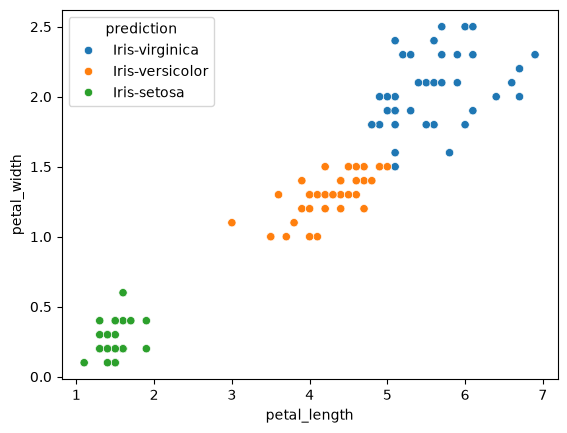

In [267]:
sns.scatterplot(x = "petal_length", y = "petal_width", hue = "prediction", data = df_predictions_cross_logistic)

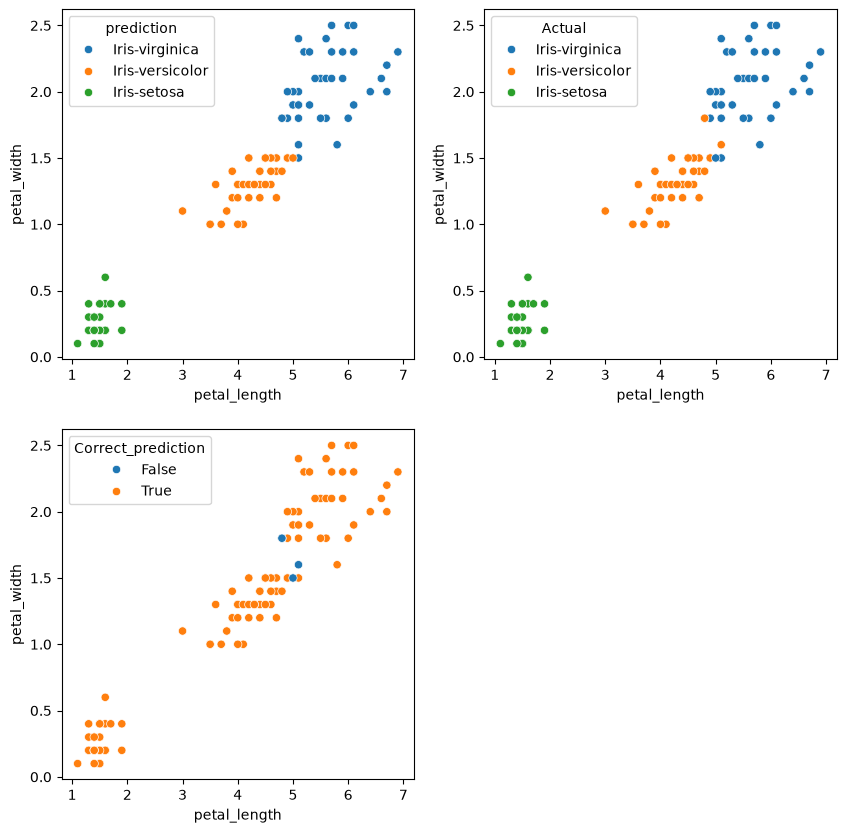

In [268]:
def plot_incorrect_predictions_logistic(df_prediction, x_axis_features, y_axis_features):
    fig, axs = plt.subplots(2,2, figsize = (10,10))
    axs = axs.flatten()
    sns.scatterplot(x = x_axis_features, y = y_axis_features, hue="prediction", data = df_prediction, ax = axs[0])
    sns.scatterplot(x = x_axis_features, y = y_axis_features, hue="Actual", data = df_prediction, ax = axs[1])
    sns.scatterplot(x = x_axis_features, y = y_axis_features, hue="Correct_prediction", data = df_prediction, ax = axs[2])
    axs[3].set_visible(False)
    



plot_incorrect_predictions_logistic(df_predictions_cross_logistic, "petal_length", "petal_width")

In [269]:
misclassified = df_predictions_cross_logistic[
    df_predictions_cross_logistic["Correct_prediction"] == False
]

print(misclassified[
    ["petal_length", "petal_width", "Actual", "prediction"]
])

     petal_length  petal_width           Actual       prediction
126           4.8          1.8   Iris-virginica  Iris-versicolor
83            5.1          1.6  Iris-versicolor   Iris-virginica
119           5.0          1.5   Iris-virginica  Iris-versicolor
70            4.8          1.8  Iris-versicolor   Iris-virginica


In [270]:
print(
    misclassified[
        ["petal_length", "petal_width"]
    ].value_counts()
)

petal_length  petal_width
4.8           1.8            2
5.1           1.6            1
5.0           1.5            1
Name: count, dtype: int64


# Model Tuning

In [271]:
for reg_param in (0.1, 0.3, 0.9, 1, 1.3, 1.9, 2):
    print(reg_param)
    model = LogisticRegression(max_iter = 200, C = reg_param)

    accuracies = cross_val_score(model,X_train,y_train,cv = 5, scoring="accuracy")
    accuracy = np.mean(accuracies)
    print(f"The accuracy of the logistic regression model is: {accuracy * 100:.2f}%")

0.1
The accuracy of the logistic regression model is: 94.62%
0.3
The accuracy of the logistic regression model is: 96.40%
0.9
The accuracy of the logistic regression model is: 96.40%
1
The accuracy of the logistic regression model is: 96.40%
1.3
The accuracy of the logistic regression model is: 96.40%
1.9
The accuracy of the logistic regression model is: 95.53%
2
The accuracy of the logistic regression model is: 94.62%


In [272]:
for reg_param in (0.3, 0.5, 0.7, 0.9, 1, 1.3, 1.5, 1.7,1.8,1.9):
    print(reg_param)
    model = LogisticRegression(max_iter = 200, C = reg_param)

    accuracies = cross_val_score(model,X_train,y_train,cv = 5, scoring="accuracy")
    accuracy = np.mean(accuracies)
    print(f"The accuracy of the logistic regression model is: {accuracy * 100:.2f}%")

0.3
The accuracy of the logistic regression model is: 96.40%
0.5
The accuracy of the logistic regression model is: 96.40%
0.7
The accuracy of the logistic regression model is: 96.40%
0.9
The accuracy of the logistic regression model is: 96.40%
1
The accuracy of the logistic regression model is: 96.40%
1.3
The accuracy of the logistic regression model is: 96.40%
1.5
The accuracy of the logistic regression model is: 96.40%
1.7
The accuracy of the logistic regression model is: 96.40%
1.8
The accuracy of the logistic regression model is: 95.53%
1.9
The accuracy of the logistic regression model is: 95.53%


# Final Model

In [273]:
model = LogisticRegression(max_iter = 200, C = 1)

accuracies = cross_val_score(model,X_train,y_train,cv = 5, scoring="accuracy")
accuracy = np.mean(accuracies)
print(f"The accuracy of the logistic regression model is: {accuracy * 100:.2f}%")

The accuracy of the logistic regression model is: 96.40%


### Looking how well this model will do on the test set

In [281]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [ ]:
y_test_pred = model.predict(X_test)
test_set_correctly_classified = y_test_pred == y_test
test_set_accuracy = np.mean(test_set_correctly_classified)
print(f"Test set accuracy: {test_set_accuracy * 100:.2f}%")

Test set accuracy: 94.74%


# Identifying the misclassified class using the graph

In [279]:
df_predictions_test = X_test.copy()
df_predictions_test["Actual"] = y_test.values
df_predictions_test["Correct_prediction"] = test_set_correctly_classified
df_predictions_test["prediction"] = y_test_pred
df_predictions_test

,sepal_length,sepal_width,petal_length,petal_width,Actual,Correct_prediction,prediction
42,4.4,3.2,1.3,0.2,Iris-setosa,True,Iris-setosa
56,6.3,3.3,4.7,1.6,Iris-versicolor,True,Iris-versicolor
99,5.7,2.8,4.1,1.3,Iris-versicolor,True,Iris-versicolor
53,5.5,2.3,4.0,1.3,Iris-versicolor,True,Iris-versicolor
38,4.4,3.0,1.3,0.2,Iris-setosa,True,Iris-setosa
85,6.0,3.4,4.5,1.6,Iris-versicolor,True,Iris-versicolor
134,6.1,2.6,5.6,1.4,Iris-virginica,True,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica,True,Iris-virginica
107,7.3,2.9,6.3,1.8,Iris-virginica,True,Iris-virginica
132,6.4,2.8,5.6,2.2,Iris-virginica,True,Iris-virginica


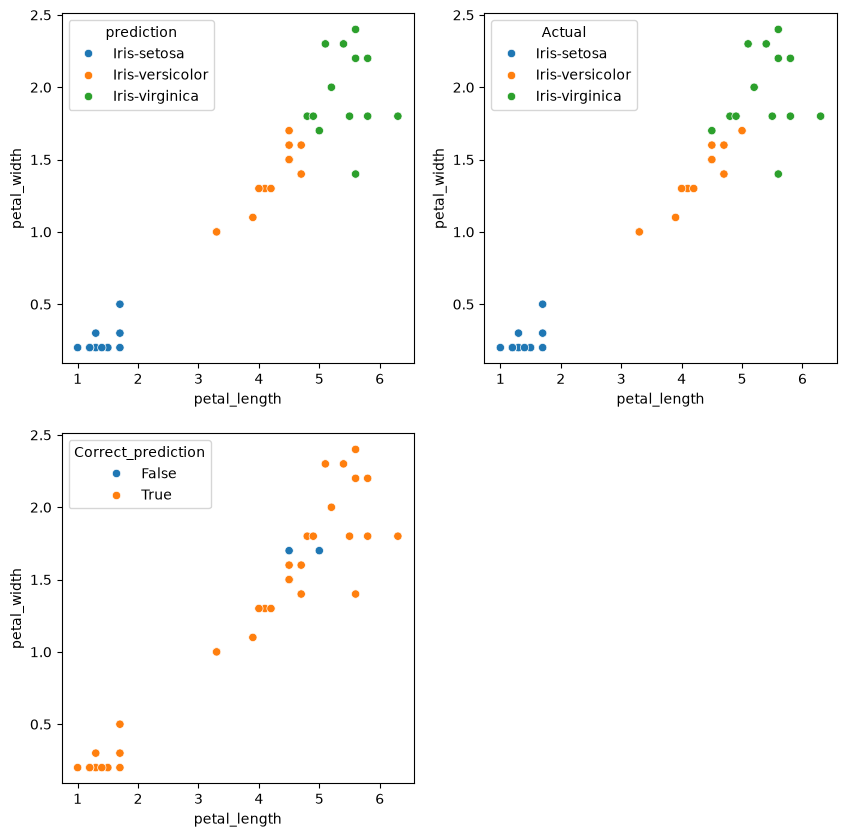

In [280]:
plot_incorrect_predictions_logistic(df_predictions_test, x_axis_features="petal_length", y_axis_features="petal_width")

# Conclusion
In conclusion, we achieved a 94.74% accuracy on the test data set using a logistic regression model with these model parameters:
```
Logistic regression(C = 1, max_iter = 200)
```